# Day 2 - EOS, relaxation, and phonons with ASE and MLIPs

This notebook runs three ASE-based tasks for Si, Al, and NaCl with one selected foundation model:

- EOS scans and Birch-Murnaghan fits
- Hydrostatic cell relaxations compared to the EOS minima
- Phonon band structures from finite displacements

Set `MODEL_KEY` to `nequip` or `mace` in the setup cell.

In [5]:
import math
import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase.io import read, write
from ase.build import bulk
from ase.filters import UnitCellFilter, FrechetCellFilter
from ase.optimize import BFGS
from ase.phonons import Phonons


In [2]:
ROOT = Path.cwd().resolve()

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("TORCH_COMPILE_DISABLE", "1")
os.environ.setdefault("TORCHINDUCTOR_DISABLE", "1")

plt.style.use("seaborn-v0_8-whitegrid")


## USER PARAMETERS

### Model

In [3]:
MODEL_KEY = "upet"  # change to "mace", "qe" for QE pw.x, or "upet" for UPET PET-MAD
MODEL_LABELS = {
    "upet": "UPET PET-MAD",
    "mace": "MACE MP-0b2-large",
    "qe": "Quantum Espresso pw.x",
}
MODEL_VERSION = {
    "upet": "pet-mad-s",
    "mace": "large-0b2",
    "qe": "7.5.0",
}


### Calculation parameters

In [ ]:
EOS_SCALE_MIN = 0.94
EOS_SCALE_MAX = 1.06
EOS_POINTS = 7
RELAX_FMAX = 0.001
RELAX_STEPS = 100
PHONON_SUPERCELL = (4,4,4)
PHONON_DELTA = 0.01
PHONON_NPOINTS = 120
OUTPUT_DIR = ROOT / "notebook_outputs" / MODEL_KEY
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

structures = {
    "Si": bulk("Si", "diamond", a=5.43, cubic=False),
    "Al": bulk("Al", "fcc", a=4.05, cubic=False),
    "NaCl": bulk("NaCl", "rocksalt", a=5.64, cubic=False),
}

PW_X_PATH = Path("/<path_to_qe>/bin/pw.x")

In [ ]:

# ibrav=2 (FCC), celldm(1)=10.50 bohr -> a = 10.50 * 0.529177 Å (zincblende AlAs)
a_ang = 10.50 * 0.529177  # Bohr to Angstrom
atoms = bulk("AlAs", "zincblende", a=a_ang)
print(atoms)
print(f"a = {a_ang:.4f} Å")
print(atoms.cell)


ValueError: ASE does not support ibrav != 0. Note that with ibrav == 0, Quantum ESPRESSO will still detect the symmetries of your system because the CELL_PARAMETERS are defined to a high level of precision.

## Helper functions

In [ ]:
def get_formula_units(atoms):
    counts = Counter(atoms.get_chemical_symbols())
    values = list(counts.values())
    result = values[0]
    for value in values[1:]:
        result = math.gcd(result, value)
    return result

def bm3_E(V, E0, V0, B0, B1):
    eta = (V0 / V) ** (2.0 / 3.0)
    t = eta - 1.0
    return E0 + (9.0 * V0 * B0 / 16.0) * (t ** 3 * B1 + t ** 2 * (6.0 - 4.0 * eta))

def fit_bm3(V, E):
    from scipy.optimize import curve_fit

    V = np.asarray(V, dtype=float)
    E = np.asarray(E, dtype=float)
    p0 = [float(np.min(E)), float(V[np.argmin(E)]), 0.5, 4.0]
    popt, _ = curve_fit(bm3_E, V, E, p0=p0, maxfev=20000)
    return tuple(map(float, popt))

def _get_nequip_calculator():
    """Return a NequIPCalculator for the OAM-L model, compiling it if needed."""
    import subprocess
    import sys
    from nequip.ase import NequIPCalculator

    MODEL_REF = "nequip.net:mir-group/NequIP-OAM-L:0.1"

    # Check candidate compiled model paths in order of preference.
    # The plain (no __cpu suffix) file may have been compiled previously.
    candidates = [
        ROOT / "mir-group__NequIP-OAM-L__0.1__cpu.nequip.pt2",
        ROOT / "mir-group__NequIP-OAM-L__0.1.nequip.pt2",
    ]
    compiled_model = next((p for p in candidates if p.exists()), candidates[0])

    if not compiled_model.exists():
        # Locate nequip-compile in the same bin/ directory as the current Python interpreter
        nequip_compile_exe = Path(sys.executable).parent / "nequip-compile"
        if not nequip_compile_exe.exists():
            raise FileNotFoundError(
                f"nequip-compile not found at {nequip_compile_exe}. "
                "Make sure nequip is installed in this kernel's environment."
            )

        print(f"Compiled model not found — running nequip-compile (this may take a few minutes)...")
        cmd = [
            str(nequip_compile_exe), MODEL_REF, str(compiled_model),
            "--mode", "aotinductor",
            "--device", "cpu",
            "--target", "ase",
        ]
        print("Running:", " ".join(cmd))
        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr)
        if result.returncode != 0:
            raise RuntimeError(
                f"nequip-compile failed (exit {result.returncode}).\n"
                f"stdout:\n{result.stdout}\nstderr:\n{result.stderr}"
            )
        print(f"Compiled model saved to {compiled_model}")
    else:
        print(f"Using existing compiled model: {compiled_model.name}")

    return NequIPCalculator.from_compiled_model(
        compile_path=str(compiled_model),
        device="cpu",
    )

def build_calculator(model_key, calculation="scf"):
    import importlib

    if model_key == "nequip":
        return _get_nequip_calculator()

    if model_key == "mace":
        mace_calculators = importlib.import_module("mace.calculators")
        return mace_calculators.mace_mp(model=MODEL_VERSION[model_key])

    if model_key == "qe":
        from ase.calculators.espresso import Espresso, EspressoProfile

        pw_exe = PW_X_PATH
        if not pw_exe.exists():
            raise FileNotFoundError(f"pw.x not found at {pw_exe}")

        pseudo_dir = Path.home() / ".espresso_pseudos"
        pseudopotentials = {
            "Si": "Si.pbe-n-kjpaw_psl.1.0.0.UPF",
            "Al": "Al.pbe-n-kjpaw_psl.1.0.0.UPF",
            "Na": "Na.pbe-spn-kjpaw_psl.1.0.0.UPF",
            "Cl": "Cl.pbe-n-kjpaw_psl.1.0.0.UPF",
        }

        input_data = {
            "control": {
                "calculation": calculation,
                "restart_mode": "from_scratch",
                "tstress": True,
                "tprnfor": True,
            },
            "system": {
                "ecutwfc": 40.0,
                "ecutrho": 320.0,
                "occupations": "smearing",
                "smearing": "methfessel-paxton",
                "degauss": 0.02,
            },
            "electrons": {
                "conv_thr": 1.0e-7,
            },
        }

        profile = EspressoProfile(command=f"mpirun -np 2 {str(pw_exe)}", pseudo_dir=str(pseudo_dir))
        return Espresso(
            profile=profile,
            pseudopotentials=pseudopotentials,
            input_data=input_data,
            kpts=(3, 3, 3),
            directory="./qe_out",
        )

    raise ValueError(f"Unknown model key: {model_key}")

calc = build_calculator(MODEL_KEY)
print(f"Using model: {MODEL_LABELS[MODEL_KEY]} ({MODEL_VERSION[MODEL_KEY]})")


Using existing compiled model: mir-group__NequIP-OAM-L__0.1__cpu.nequip.pt2
Using model: NequIP OAM-L (nequip-oam-l)


/home/vojace_l/miniforge3/envs/mlip-nequip/lib/python3.11/site-packages/nequip/ase/nequip_calculator.py:59: UserWarning: Defaulting to using model type names as chemical symbols. If the model type names correspond exactly to chemical species (e.g., 'H', 'C', 'O'), this is correct. Otherwise, this is wrong and will cause errors. To silence this warning, explicitly set `chemical_species_to_atom_type_map=True` for identity mapping, or provide the correct mapping as a dict.
  warnings.warn(


## 0. Visualize the crystal structures

Before any calculation, let's take a look at the three test systems. Si (diamond cubic), Al (fcc), and NaCl (rock-salt) are classic benchmarks covering a covalent semiconductor, a simple metal, and an ionic compound — a good spread of bonding characters for testing a foundation model.


In [16]:
import chemiscope, ipywidgets as widgets, math; from collections import Counter
SUPERCELL = (3,3,3)
atoms=list(structures.values())
names=list(structures.keys())
vfu=[a.get_volume()/math.gcd(*Counter(a.get_chemical_symbols()).values()) for a in atoms]
widgets.HBox([(lambda w: (setattr(w, "layout", widgets.Layout(width="260px", height="450px")) or w))(chemiscope.show(structures=atoms, mode="map", properties={"index": {"target": "structure", "values": list(range(len(atoms)))}, "volume_per_fu": {"target": "structure", "values": vfu}, "name": {"target": "structure", "values": names}}, settings={"map": {"x": {"property": "index"}, "y": {"property": "volume_per_fu"}, "symbol": "name"}})), widgets.GridBox([(lambda w: (setattr(w, "layout", widgets.Layout(width="450px", height="450px")) or w))(chemiscope.show(structures=[a], mode="structure", settings={"structure": [{"unitCell": True, "supercell": {"0": SUPERCELL[0], "1": SUPERCELL[1], "2": SUPERCELL[2]}, "bonds": True, "spaceFilling": False, "keepOrientation": True}]})) for a in atoms], layout=widgets.Layout(grid_template_columns="repeat(3, 450px)", grid_template_rows="450px", grid_gap="8px"))], layout=widgets.Layout(width="100%", align_items="flex-start", gap="12px"))

## 1. Equation of state

We scale the unit cell isotropically over a range of volumes and evaluate the total energy at each point. Fitting a 3rd-order Birch–Murnaghan (BM3) EOS to the resulting $E(V)$ curve yields the equilibrium volume $V_0$, the cohesive energy $E_0$, the bulk modulus $B_0$, and its pressure derivative $B_1'$. This is a cheap and model-independent way to probe the energy landscape around the ground state.


[1] Si: V0 = 20.3348 A^3/f.u., E0 = -5.411973 eV/f.u., B0 = 86.76 GPa, B1 = 4.104
[1] Al: V0 = 16.4994 A^3/f.u., E0 = -3.741111 eV/f.u., B0 = 79.20 GPa, B1 = 4.984
[1] NaCl: V0 = 46.4900 A^3/f.u., E0 = -6.770002 eV/f.u., B0 = 23.57 GPa, B1 = 4.607
Saved /home/vojace_l/OneDrive/Dokumenty/PSI-vojac/MLIPs/foundation-MLIPs_comparison/notebook_outputs/nequip/nequip_eos.png


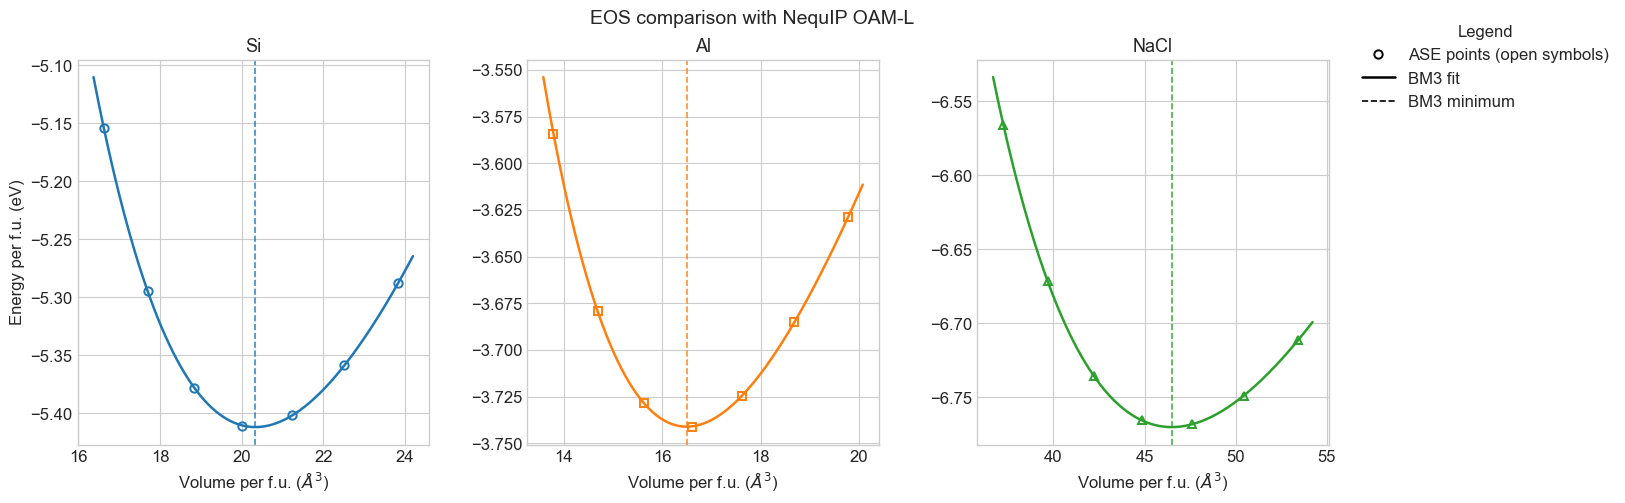

In [17]:
from matplotlib.lines import Line2D

eos_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.0))
fig.subplots_adjust(right=0.82, wspace=0.28)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
markers = {"Si": "o", "Al": "s", "NaCl": "^"}

for idx, (ax, (name, atoms0)) in enumerate(zip(axes, structures.items())):
    scale_values = np.linspace(EOS_SCALE_MIN, EOS_SCALE_MAX, EOS_POINTS)
    volumes_total = []
    energies_total = []

    for i, scale in enumerate(scale_values):
        print(f"{i+1}/{len(scale_values)} scale {scale:.4f}...", end="\r")
        atoms = atoms0.copy()
        atoms.set_cell(atoms.cell * scale, scale_atoms=True)
        if hasattr(calc, 'directory'):
            calc.directory = Path(f"./qe_out_{name.lower()}_eos/scale_{i+1:02d}")
        atoms.calc = calc
        volumes_total.append(float(atoms.get_volume()))
        energies_total.append(float(atoms.get_potential_energy()))

    n_atoms = len(atoms0)
    n_fu = get_formula_units(atoms0)
    volumes = np.array(volumes_total) / n_fu
    energies = np.array(energies_total) / n_fu
    E0, V0, B0, B1 = fit_bm3(volumes, energies)

    volume_fit = np.linspace(volumes.min() * 0.985, volumes.max() * 1.015, 250)
    energy_fit = bm3_E(volume_fit, E0, V0, B0, B1)
    color = colors[idx % len(colors)]

    eos_results[name] = {
        "structure": atoms0.copy(),
        "n_atoms": n_atoms,
        "n_fu": n_fu,
        "scale_values": scale_values,
        "volume_total_A3": np.array(volumes_total),
        "energy_total_eV": np.array(energies_total),
        "volume_per_fu_A3": volumes,
        "energy_per_fu_eV": energies,
        "fit": {
            "E0_eV_per_fu": E0,
            "V0_A3_per_fu": V0,
            "B0_eV_per_A3": B0,
            "B1_dimensionless": B1,
            "B0_GPa": B0 * 160.21766208,
        },
    }

    ax.plot(
        volumes,
        energies,
        marker=markers[name],
        linestyle="none",
        color=color,
        markerfacecolor="none",
        markeredgecolor=color,
        markeredgewidth=1.4,
        markersize=6,
    )
    ax.plot(volume_fit, energy_fit, color=color, linewidth=1.8)
    ax.axvline(V0, color=color, linestyle="--", linewidth=1.2, alpha=0.85)

    ax.set_title(name, fontsize=13)
    ax.set_xlabel(r"Volume per f.u. ($\AA^3$)", fontsize=12)
    ax.tick_params(axis="both", labelsize=12)

    print(f"[1] {name}: V0 = {V0:.4f} A^3/f.u., E0 = {E0:.6f} eV/f.u., B0 = {B0 * 160.21766208:.2f} GPa, B1 = {B1:.3f}")

axes[0].set_ylabel(r"Energy per f.u. (eV)", fontsize=12)

eos_handles = [
    Line2D([0], [0], marker="o", linestyle="none", color="k", markerfacecolor="none", markeredgecolor="k", markeredgewidth=1.4, markersize=6, label="ASE points (open symbols)"),
    Line2D([0], [0], linestyle="-", color="k", linewidth=1.8, label="BM3 fit"),
    Line2D([0], [0], linestyle="--", color="k", linewidth=1.2, label="BM3 minimum"),
]
fig.legend(handles=eos_handles, loc="upper left", bbox_to_anchor=(0.83, 0.98), fontsize=12, title="Legend", title_fontsize=12)
fig.suptitle(f"EOS comparison with {MODEL_LABELS[MODEL_KEY]}", fontsize=14)

eos_plot_path = OUTPUT_DIR / f"{MODEL_KEY}_eos.png"
fig.savefig(eos_plot_path, dpi=220)
print(f"Saved {eos_plot_path}")


## 2. Structural relaxation

Now we let the cell relax freely using ASE's `FrechetCellFilter` with hydrostatic strain, which allows the volume to change while preserving the crystal symmetry. The optimizer converges when the maximum force component drops below `RELAX_FMAX`. Comparing the relaxed volume $V_\text{relax}$ and energy $E_\text{relax}$ to the BM3 minimum $V_0$/$E_0$ is a sanity check: they should agree closely if the EOS scan was dense enough and the model is well-behaved.


### 2.a. Relax

In [18]:
relax_results = {}
relaxed_atoms = {}

for name, atoms0 in structures.items():
    atoms = atoms0.copy()

    if MODEL_KEY == "qe":
        # For QE we use vc-relax: QE handles ionic + cell relaxation internally.
        # A fresh calculator with calculation="vc-relax" is built for each structure
        # so the output directory is set correctly before the calculator is created.
        qe_relax = build_calculator(MODEL_KEY, calculation="vc-relax")
        qe_relax.directory = Path(f"./qe_out_{name.lower()}_relax")
        atoms.calc = qe_relax
        atoms.get_potential_energy()   # triggers QE vc-relax; atoms is updated in place
    else:
        atoms.calc = calc
        ucf = FrechetCellFilter(atoms, hydrostatic_strain=True)
        opt = BFGS(ucf, logfile=None)
        opt.run(fmax=RELAX_FMAX, steps=RELAX_STEPS)
        atoms = ucf.atoms

    relaxed_atoms[name] = atoms.copy()

    n_fu = get_formula_units(atoms0)
    e_relax = float(atoms.get_potential_energy()) / n_fu
    v_relax = float(atoms.get_volume()) / n_fu

    e0 = eos_results[name]["fit"]["E0_eV_per_fu"]
    v0 = eos_results[name]["fit"]["V0_A3_per_fu"]

    relax_results[name] = {
        "E_relax_eV_per_fu": e_relax,
        "V_relax_A3_per_fu": v_relax,
        "E0_EOS_eV_per_fu": e0,
        "V0_EOS_A3_per_fu": v0,
        "dE_meV_per_fu": 1000.0 * (e_relax - e0),
        "dV_percent": 100.0 * (v_relax - v0) / v0,
        "n_atoms": len(atoms),
        "n_fu": n_fu,
        "final_cell": atoms.cell.array.copy(),
        "final_positions": atoms.positions.copy(),
    }

    print(
        f"[2] {name}: V_relax = {v_relax:.4f} A^3/f.u. vs V0 = {v0:.4f} A^3/f.u. | "
        f"dV = {relax_results[name]['dV_percent']:+.2f}% | "
        f"E_relax = {e_relax:.6f} eV/f.u. vs E0 = {e0:.6f} eV/f.u. | "
        f"dE = {relax_results[name]['dE_meV_per_fu']:+.2f} meV/f.u."
    )


[2] Si: V_relax = 20.3204 A^3/f.u. vs V0 = 20.3348 A^3/f.u. | dV = -0.07% | E_relax = -5.412367 eV/f.u. vs E0 = -5.411973 eV/f.u. | dE = -0.39 meV/f.u.
[2] Al: V_relax = 16.4967 A^3/f.u. vs V0 = 16.4994 A^3/f.u. | dV = -0.02% | E_relax = -3.741515 eV/f.u. vs E0 = -3.741111 eV/f.u. | dE = -0.40 meV/f.u.
[2] NaCl: V_relax = 46.4868 A^3/f.u. vs V0 = 46.4900 A^3/f.u. | dV = -0.01% | E_relax = -6.770008 eV/f.u. vs E0 = -6.770002 eV/f.u. | dE = -0.01 meV/f.u.


### 2.b. Plot relaxed volume on top of EOS results

Saved /home/vojace_l/OneDrive/Dokumenty/PSI-vojac/MLIPs/foundation-MLIPs_comparison/notebook_outputs/nequip/nequip_relaxation_comparison.png


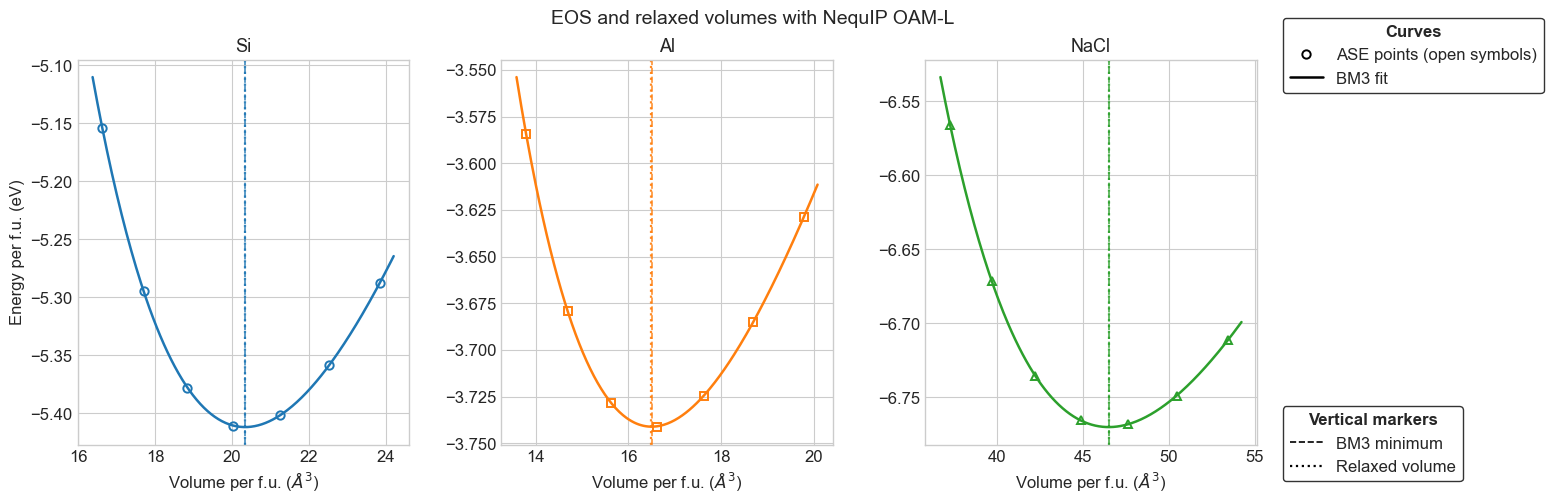

In [19]:


from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.0))
fig.subplots_adjust(right=0.78, wspace=0.28)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
markers = {"Si": "o", "Al": "s", "NaCl": "^"}

for idx, (ax, name) in enumerate(zip(axes, structures.keys())):
    data = eos_results[name]
    fit = data["fit"]
    volume_fit = np.linspace(data["volume_per_fu_A3"].min() * 0.985, data["volume_per_fu_A3"].max() * 1.015, 250)
    energy_fit = bm3_E(volume_fit, fit["E0_eV_per_fu"], fit["V0_A3_per_fu"], fit["B0_eV_per_A3"], fit["B1_dimensionless"])
    color = colors[idx % len(colors)]

    ax.plot(
        data["volume_per_fu_A3"],
        data["energy_per_fu_eV"],
        marker=markers[name],
        linestyle="none",
        color=color,
        markerfacecolor="none",
        markeredgecolor=color,
        markeredgewidth=1.4,
        markersize=6,
    )
    ax.plot(volume_fit, energy_fit, color=color, linewidth=1.8)
    ax.axvline(fit["V0_A3_per_fu"], color=color, linestyle="--", linewidth=1.2, alpha=0.85)
    ax.axvline(relax_results[name]["V_relax_A3_per_fu"], color=color, linestyle=":", linewidth=1.6, alpha=0.9)

    ax.set_title(name, fontsize=13)
    ax.set_xlabel(r"Volume per f.u. ($\AA^3$)", fontsize=12)
    ax.tick_params(axis="both", labelsize=12)

axes[0].set_ylabel(r"Energy per f.u. (eV)", fontsize=12)
fig.suptitle(f"EOS and relaxed volumes with {MODEL_LABELS[MODEL_KEY]}", fontsize=14)

series_handles = [
    Line2D([0], [0], marker="o", linestyle="none", color="k", markerfacecolor="none", markeredgecolor="k", markeredgewidth=1.4, markersize=6, label="ASE points (open symbols)"),
    Line2D([0], [0], linestyle="-", color="k", linewidth=1.8, label="BM3 fit"),
]
vertical_handles = [
    Line2D([0], [0], linestyle="--", color="k", linewidth=1.2, label="BM3 minimum"),
    Line2D([0], [0], linestyle=":", color="k", linewidth=1.6, label="Relaxed volume"),
]

leg1 = fig.legend(handles=series_handles, fontsize=12, loc="upper left", bbox_to_anchor=(0.79, 0.98), title="Curves", title_fontsize=12, frameon=True, edgecolor="black")
leg1.get_title().set_fontweight("bold")
leg2 = fig.legend(handles=vertical_handles, fontsize=12, loc="lower left", bbox_to_anchor=(0.79, 0.02), title="Vertical markers", title_fontsize=12, frameon=True, edgecolor="black")
leg2.get_title().set_fontweight("bold")

relax_plot_path = OUTPUT_DIR / f"{MODEL_KEY}_relaxation_comparison.png"
fig.savefig(relax_plot_path, dpi=220)
print(f"Saved {relax_plot_path}")


## 3. Phonon band structures

Phonons are the normal modes of atomic vibrations in a crystal. We compute them via the finite-displacement method: each atom in a supercell is slightly displaced ($\delta =$ `PHONON_DELTA` Å) and the resulting forces are used to build the force-constant matrix. Diagonalising it along a high-symmetry **k**-path gives the phonon dispersion. Imaginary frequencies (plotted as negative) indicate a dynamical instability. We start from the relaxed structures so that the forces at the undisplaced geometry are zero.


[3] Si: starting phonons (768 displacements expected)
  [Si] displacement 1/768


  [Si] displacement 2/768
  [Si] displacement 3/768
  [Si] displacement 4/768
  [Si] displacement 5/768
  [Si] displacement 6/768
  [Si] displacement 7/768
  [Si] displacement 8/768
  [Si] displacement 9/768
  [Si] displacement 10/768
  [Si] displacement 11/768
  [Si] displacement 12/768
  [Si] displacement 13/768
WARNING, 2 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 2.293e-03*i)
WARNING, 1 imaginary frequencies at q = ( 0.03,  0.00,  0.03) ; (omega_q = 4.984e-03*i)
WARNING, 2 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 2.293e-03*i)
WARNING, 1 imaginary frequencies at q = ( 0.03,  0.03,  0.03) ; (omega_q = 1.594e-02*i)
[3] Si: done — supercell=(4, 4, 4), delta=0.010 A, npoints=120, freq range=[-1.03, 58.45] meV
[3] Al: starting phonons (384 displacements expected)
  [Al] displacement 1/384
  [Al] displacement 2/384
  [Al] displacement 3/384
  [Al] displacement 4/384
  [Al] displacement 5/384
  [Al] displacement 6/384
  [Al] displacement 7/384
WA

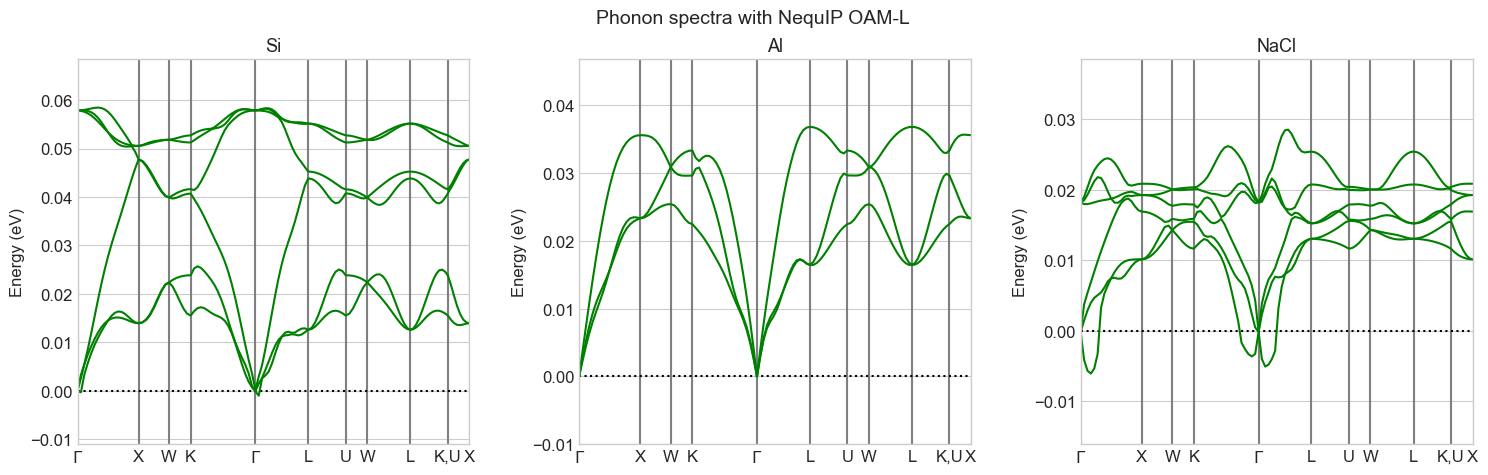

In [20]:
phonon_results = {}

import shutil
shutil.rmtree("phonon", ignore_errors=True)

fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.0))
fig.subplots_adjust(wspace=0.28)

for ax, name in zip(axes, structures.keys()):
    atoms = relaxed_atoms[name].copy()
    if hasattr(calc, 'directory'):
        calc.directory = Path(f"./qe_out_{name.lower()}_phonons")

    # Wrap calculator to print progress on each displacement SCF
    n_expected = 6 * len(atoms) * PHONON_SUPERCELL[0] * PHONON_SUPERCELL[1] * PHONON_SUPERCELL[2]
    counter = [0]
    base_calc = calc

    class _VerboseCalc:
        def __init__(self, wrapped):
            self._w = wrapped
        def get_forces(self, a):
            counter[0] += 1
            print(f"  [{name}] displacement {counter[0]}/{n_expected}", flush=True)
            return self._w.get_forces(a)
        def __getattr__(self, item):
            return getattr(self._w, item)

    verbose_calc = _VerboseCalc(base_calc)
    atoms.calc = verbose_calc
    print(f"[3] {name}: starting phonons ({n_expected} displacements expected)")

    ph = Phonons(atoms, verbose_calc, supercell=PHONON_SUPERCELL, delta=PHONON_DELTA)
    ph.run()
    ph.read(acoustic=True)
    path = atoms.cell.bandpath(npoints=PHONON_NPOINTS)
    band_structure = ph.get_band_structure(path)

    phonon_results[name] = {
        "path": path,
        "band_structure": band_structure,
    }

    band_structure.plot(ax=ax)
    ax.set_title(name, fontsize=13)
    ax.tick_params(axis="both", labelsize=12)

    ax.set_ylim((np.min(band_structure.energies) - 0.01, np.max(band_structure.energies) + 0.01))

    energies = np.asarray(band_structure.energies)
    print(
        f"[3] {name}: done — supercell={PHONON_SUPERCELL}, "
        f"delta={PHONON_DELTA:.3f} A, npoints={PHONON_NPOINTS}, "
        f"freq range=[{np.nanmin(energies)*1000:.2f}, {np.nanmax(energies)*1000:.2f}] meV"
    )

    ph.clean()

    ax.set_ylabel("Energy (eV)", fontsize=12)
    
fig.suptitle(f"Phonon spectra with {MODEL_LABELS[MODEL_KEY]}", fontsize=14)

phonon_plot_path = OUTPUT_DIR / f"{MODEL_KEY}_phonons.png"
fig.savefig(phonon_plot_path, dpi=220)
print(f"Saved {phonon_plot_path}")


## Summary

All results are collected in the dictionaries `eos_results`, `relax_results`, `relaxed_atoms`, and `phonon_results` for further analysis. The table below gives a concise numerical overview: EOS-fitted $V_0$, $B_0$, and $B_1'$; the deviation of the relaxed volume from the EOS minimum; and the phonon calculation settings used.


In [21]:
import pandas as pd
from IPython.display import display

rows_eos = []
rows_relax = []
rows_phonon = []

for name in structures.keys():
    eos = eos_results[name]["fit"]
    rel = relax_results[name]
    rows_eos.append(
        {
            "Structure": name,
            r"V0 EOS ($\AA^3$/f.u.)": eos["V0_A3_per_fu"],
            r"E0 EOS (eV/f.u.)": eos["E0_eV_per_fu"],
            r"B0 (GPa)": eos["B0_GPa"],
            r"B1": eos["B1_dimensionless"],
        }
    )
    rows_relax.append(
        {
            "Structure": name,
            r"V relax ($\AA^3$/f.u.)": rel["V_relax_A3_per_fu"],
            r"E relax (eV/f.u.)": rel["E_relax_eV_per_fu"],
            r"V0 EOS ($\AA^3$/f.u.)": rel["V0_EOS_A3_per_fu"],
            r"dV (%)": rel["dV_percent"],
            r"dE (meV/f.u.)": rel["dE_meV_per_fu"],
        }
    )
    rows_phonon.append(
        {
            "Structure": name,
            "Supercell": "x".join(map(str, PHONON_SUPERCELL)),
            r"Delta ($\AA$)": PHONON_DELTA,
            "npoints": PHONON_NPOINTS,
            "Path": "default bandpath",
        }
    )

eos_table = pd.DataFrame(rows_eos).set_index("Structure")
relax_table = pd.DataFrame(rows_relax).set_index("Structure")
phonon_table = pd.DataFrame(rows_phonon).set_index("Structure")

display(eos_table.style.format({
    r"V0 EOS ($\AA^3$/f.u.)": "{:.4f}",
    r"E0 EOS (eV/f.u.)": "{:.6f}",
    r"B0 (GPa)": "{:.2f}",
    r"B1": "{:.3f}",
}))

display(relax_table.style.format({
    r"V relax ($\AA^3$/f.u.)": "{:.4f}",
    r"E relax (eV/f.u.)": "{:.6f}",
    r"V0 EOS ($\AA^3$/f.u.)": "{:.4f}",
    r"dV (%)": "{:+.2f}",
    r"dE (meV/f.u.)": "{:+.2f}",
}))

display(phonon_table)

print(f"Outputs saved under: {OUTPUT_DIR}")


,V0 EOS ($\AA^3$/f.u.),E0 EOS (eV/f.u.),B0 (GPa),B1
Structure,,,,
Si,20.3348,-5.411973,86.76,4.104
Al,16.4994,-3.741111,79.20,4.984
NaCl,46.4900,-6.770002,23.57,4.607


,V relax ($\AA^3$/f.u.),E relax (eV/f.u.),V0 EOS ($\AA^3$/f.u.),dV (%),dE (meV/f.u.)
Structure,,,,,
Si,20.3204,-5.412367,20.3348,-0.07,-0.39
Al,16.4967,-3.741515,16.4994,-0.02,-0.40
NaCl,46.4868,-6.770008,46.4900,-0.01,-0.01


,Supercell,Delta ($\AA$),npoints,Path
Structure,,,,
Si,4x4x4,0.01,120,default bandpath
Al,4x4x4,0.01,120,default bandpath
NaCl,4x4x4,0.01,120,default bandpath


Outputs saved under: /home/vojace_l/OneDrive/Dokumenty/PSI-vojac/MLIPs/foundation-MLIPs_comparison/notebook_outputs/nequip
